In [ ]:
import tensorflow as tf
from keras.api.models import Sequential
from keras.api.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, RandomFlip, RandomRotation, RandomZoom,
    Rescaling, SeparableConv2D, BatchNormalization, Activation, GlobalAveragePooling2D, AveragePooling2D,
    Resizing, RandomTranslation, RandomBrightness, RandomContrast)
from keras.api.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.api.regularizers import l2
from keras.api.utils import image_dataset_from_directory
import os
import matplotlib.pyplot as plt
from keras.api import layers
from keras.api.models import Model

In [ ]:
EMOTIONS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

NUM_CLASSES = 7

In [ ]:
!unzip fer2013.zip

Output streaming troncato alle ultime 5000 righe.
  inflating: train/sad/Training_65242339.jpg  
  inflating: train/sad/Training_65267116.jpg  
  inflating: train/sad/Training_65275626.jpg  
  inflating: train/sad/Training_6529266.jpg  
  inflating: train/sad/Training_65329617.jpg  
  inflating: train/sad/Training_65338712.jpg  
  inflating: train/sad/Training_65338797.jpg  
  inflating: train/sad/Training_65387162.jpg  
  inflating: train/sad/Training_65404494.jpg  
  inflating: train/sad/Training_65426218.jpg  
  inflating: train/sad/Training_65430136.jpg  
  inflating: train/sad/Training_65437377.jpg  
  inflating: train/sad/Training_6545735.jpg  
  inflating: train/sad/Training_65463385.jpg  
  inflating: train/sad/Training_65473985.jpg  
  inflating: train/sad/Training_65502829.jpg  
  inflating: train/sad/Training_65505359.jpg  
  inflating: train/sad/Training_65508578.jpg  
  inflating: train/sad/Training_65516023.jpg  
  inflating: train/sad/Training_65524027.jpg  
  inflating:

In [ ]:
def prepocess_face_dataset(input_shape, batch_size):

    train_dir = os.path.join('/content/train')
    val_dir = os.path.join('/content/test')

    train_dataset = image_dataset_from_directory(
            directory=train_dir,
            label_mode='categorical',
            #subset='training',
            seed=123,
            #validation_split=0.15,
            image_size=input_shape[:2],
            color_mode='grayscale',
            batch_size=batch_size
    )

    val_dataset = image_dataset_from_directory(
        directory=val_dir,
        label_mode='categorical',
        #subset='validation',
        seed=123,
        #validation_split=0.15,
        image_size=input_shape[:2],
        color_mode='grayscale',
        batch_size=batch_size
    )

    normalization_layer = Rescaling(1./255)
    data_augmentation = Sequential([
        RandomFlip("horizontal", input_shape=input_shape[:2]),
        RandomRotation(0.1)
        ])

    train_dataset = preprocess_data_images(dataset=train_dataset, input_shape=input_shape, batch_size=batch_size, augment=False)
    val_dataset = preprocess_data_images(dataset=val_dataset, input_shape=input_shape,batch_size=batch_size, augment=False)

    return train_dataset, val_dataset

def preprocess_data_images(dataset, input_shape, batch_size: int, augment=False):
    """metodo per pre-elaborazione (normalization, rescaling, augmentation, shuffle, prefetch) direttamente sui dati prima di essere data in input al modello
    Args:
        dataset (_type_): _description_
        type_dataset (str): _description_
        batch_size (int): _description_
        augment (bool, optional): _description_. Defaults to False.

    Returns:
        dataset (_type_): _description_
    """
    # Add Rescaling layer to normalize pixel values
    normalization_layer = Rescaling(1./255)
    dataset = dataset.map(lambda x, y: (normalization_layer(x, training=True), y))

    if augment==True:
        # applicazione aumento dei dati
        data_augmentation = Sequential([
        RandomFlip("horizontal", input_shape=input_shape[:2]),
        RandomRotation(0.1)
        ])
        dataset = dataset.map(lambda x, y: (data_augmentation(x, training=True), y))

    # cache mantiene le immagini in memoria dopo che sono state caricate dal disco durante la prima epoca. Ciò garantirà che il set di dati non diventi un collo di bottiglia durante l'addestramento del modello
    # prefetch sovrappone alla preelaborazione dei dati e all'esecuzione del modello durante l'addestramento
    dataset = dataset.shuffle(1000)

    return dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

## **MiniXception**

In [ ]:
class ModelMiniXception:
    def __init__(self, num_classes: int, input_shape, batch_size: int) -> None:
        self.num_classes = num_classes
        self.input_shape = input_shape
        self.batch_size = batch_size
        self.model = self._create_model()

    def _create_model(self, l2_regularization=0.01):

        regularization = l2(l2_regularization)

        # base
        img_input = Input(self.input_shape)
        x = Conv2D(8, (3, 3), strides=(1, 1), kernel_regularizer=regularization, use_bias=False)(img_input)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Conv2D(8, (3, 3), strides=(1, 1), kernel_regularizer=regularization, use_bias=False)(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)

        # module 1
        residual = Conv2D(16, (1, 1), strides=(2, 2), padding='same', use_bias=False)(x)
        residual = BatchNormalization()(residual)
        x = SeparableConv2D(16, (3, 3), padding='same', depthwise_regularizer=regularization, pointwise_regularizer=regularization,use_bias=False)(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = SeparableConv2D(16, (3, 3), padding='same', depthwise_regularizer=regularization, pointwise_regularizer=regularization, use_bias=False)(x)
        x = BatchNormalization()(x)
        x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
        x = layers.add([x, residual])

        # module 2
        residual = Conv2D(32, (1, 1), strides=(2, 2), padding='same', use_bias=False)(x)
        residual = BatchNormalization()(residual)
        x = SeparableConv2D(32, (3, 3), padding='same', depthwise_regularizer=regularization, pointwise_regularizer=regularization, use_bias=False)(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = SeparableConv2D(32, (3, 3), padding='same', depthwise_regularizer=regularization, pointwise_regularizer=regularization, use_bias=False)(x)
        x = BatchNormalization()(x)
        x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
        x = layers.add([x, residual])

        # module 3
        residual = Conv2D(64, (1, 1), strides=(2, 2), padding='same', use_bias=False)(x)
        residual = BatchNormalization()(residual)
        x = SeparableConv2D(64, (3, 3), padding='same', depthwise_regularizer=regularization, pointwise_regularizer=regularization, use_bias=False)(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = SeparableConv2D(64, (3, 3), padding='same', depthwise_regularizer=regularization, pointwise_regularizer=regularization, use_bias=False)(x)
        x = BatchNormalization()(x)
        x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
        x = layers.add([x, residual])

        # module 4
        residual = Conv2D(128, (1, 1), strides=(2, 2), padding='same', use_bias=False)(x)
        residual = BatchNormalization()(residual)
        x = SeparableConv2D(128, (3, 3), padding='same', depthwise_regularizer=regularization, pointwise_regularizer=regularization, use_bias=False)(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = SeparableConv2D(128, (3, 3), padding='same', depthwise_regularizer=regularization, pointwise_regularizer=regularization, use_bias=False)(x)
        x = BatchNormalization()(x)
        x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
        x = layers.add([x, residual])

        x = Conv2D(self.num_classes, (3, 3), padding='same')(x)
        x = GlobalAveragePooling2D()(x)
        output = Activation('softmax', name='predictions')(x)

        model = Model(img_input, output)

        print(f"Creating Model ...\n")
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        print(f"Model Summary : \n")
        model.summary()

        return model

    def train_face_model(self, epochs=100, patience=50, verbose=1):

        print(f"Loading and preprocess the data ...\n")
        train, validation = prepocess_face_dataset(self.input_shape, self.batch_size)

        # add callbacks
        early_stop = EarlyStopping('val_loss', patience=10)
        reduce_lr = ReduceLROnPlateau('val_loss', factor=0.1, patience=5, verbose=1) # Reduce learning rate when a metric has stopped improving
        checkpoint_models_path = 'models/face/mini_xception2_'+'checkpoint.model.keras'
        model_checkpoint = ModelCheckpoint(filepath=checkpoint_models_path, monitor='val_loss', verbose=verbose, save_best_only=True)
        callbacks = [model_checkpoint, early_stop, reduce_lr]
        print(f"add callbacks ...\n")

        print(f"Start training ... \n")
        history = self.model.fit(train, batch_size=self.batch_size, epochs=epochs, validation_data=validation, callbacks=callbacks)

        return history

In [ ]:
del face_miniX_model

In [ ]:
face_miniX_model = ModelMiniXception(num_classes=NUM_CLASSES, input_shape=(48,48,1), batch_size=32)

Creating Model ...

Model Summary : 



Model: "functional_79"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 48, 48, 1)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_28 (Conv2D)        │ (None, 46, 46, 8)      │             72 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_32    │ (None, 46, 46, 8)      │             32 │ conv2d_28[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_14             │ (None, 46, 46, 8)      │              0 │ batch_normalization_3… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_29 (Conv2D)        │ (None, 44, 44, 8)      │            576 │ activation_14[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_33    │ (None, 44, 44, 8)      │             32 │ conv2d_29[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_15             │ (None, 44, 44, 8)      │              0 │ batch_normalization_3… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_8        │ (None, 44, 44, 16)     │            200 │ activation_15[0][0]    │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_35    │ (None, 44, 44, 16)     │             64 │ separable_conv2d_8[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_16             │ (None, 44, 44, 16)     │              0 │ batch_normalization_3… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_9        │ (None, 44, 44, 16)     │            400 │ activation_16[0][0]    │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_36    │ (None, 44, 44, 16)     │             64 │ separable_conv2d_9[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_30 (Conv2D)        │ (None, 22, 22, 16)     │            128 │ activation_15[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_7           │ (None, 22, 22, 16)     │              0 │ batch_normalization_3… │
│ (MaxPooling2D)            │                        │                │                        │
├──────────────────────

 Total params: 58,423 (228.21 KB)

 Trainable params: 56,951 (222.46 KB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
del face_miniX_history

In [ ]:
face_miniX_history = face_miniX_model.train_face_model()

Loading and preprocess the data ...

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
add callbacks ...

Start training ... 

Epoch 1/100
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.3248 - loss: 1.9432
Epoch 1: val_loss improved from inf to 1.73161, saving model to models/face/mini_xception_checkpoint.model.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 241s 253ms/step - accuracy: 0.3248 - loss: 1.9431 - val_accuracy: 0.3544 - val_loss: 1.7316 - learning_rate: 0.0010
Epoch 2/100
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.4794 - loss: 1.5056
Epoch 2: val_loss improved from 1.73161 to 1.59367, saving model to models/face/mini_xception_checkpoint.model.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 258s 252ms/step - accuracy: 0.4794 - loss: 1.5056 - val_accuracy: 0.4028 - val_loss: 1.5937 - learning_rate: 0.0010
Epoch 3/100
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.5255 - loss: 1.3500
Epoch 3: val_loss did not improve from 1.59367
898/89

KeyboardInterrupt: 

In [ ]:
del face_miniX_model2

In [ ]:
face_miniX_model2 = ModelMiniXception(num_classes=NUM_CLASSES, input_shape=(48,48,1), batch_size=32)

Creating Model ...

Model Summary : 



Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7             │ (None, 48, 48, 1)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_29 (Conv2D)        │ (None, 46, 46, 8)      │             72 │ input_layer_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_55    │ (None, 46, 46, 8)      │             32 │ conv2d_29[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_25             │ (None, 46, 46, 8)      │              0 │ batch_normalization_5… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_30 (Conv2D)        │ (None, 44, 44, 8)      │            576 │ activation_25[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_56    │ (None, 44, 44, 8)      │             32 │ conv2d_30[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_26             │ (None, 44, 44, 8)      │              0 │ batch_normalization_5… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_31       │ (None, 44, 44, 16)     │            200 │ activation_26[0][0]    │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_58    │ (None, 44, 44, 16)     │             64 │ separable_conv2d_31[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_27             │ (None, 44, 44, 16)     │              0 │ batch_normalization_5… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_32       │ (None, 44, 44, 16)     │            400 │ activation_27[0][0]    │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_59    │ (None, 44, 44, 16)     │             64 │ separable_conv2d_32[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_31 (Conv2D)        │ (None, 22, 22, 16)     │            128 │ activation_26[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_14          │ (None, 22, 22, 16)     │              0 │ batch_normalization_5… │
│ (MaxPooling2D)            │                        │                │                        │
├──────────────────────

 Total params: 58,423 (228.21 KB)

 Trainable params: 56,951 (222.46 KB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
face_miniX2_history2 = face_miniX_model2.train_face_model()

Loading and preprocess the data ...

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
add callbacks ...

Start training ... 

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.3332 - loss: 3.9992
Epoch 1: val_loss improved from inf to 1.96098, saving model to models/face/mini_xception2_checkpoint.model.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 250s 263ms/step - accuracy: 0.3333 - loss: 3.9979 - val_accuracy: 0.4044 - val_loss: 1.9610 - learning_rate: 0.0010
Epoch 2/100
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.4667 - loss: 1.7313
Epoch 2: val_loss improved from 1.96098 to 1.72881, saving model to models/face/mini_xception2_checkpoint.model.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 263s 267ms/step - accuracy: 0.4667 - loss: 1.7312 - val_accuracy: 0.4416 - val_loss: 1.7288 - learning_rate: 0.0010
Epoch 3/100
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.5015 - loss: 1.5127
Epoch 3: val_loss improved from 1.72881 to 1.50244, saving model to models/face/mini_xception2_checkpoint.model.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 230s 257ms/step - accuracy: 0.5015 - loss: 1.5127 - val_accuracy: 0.5020 - v

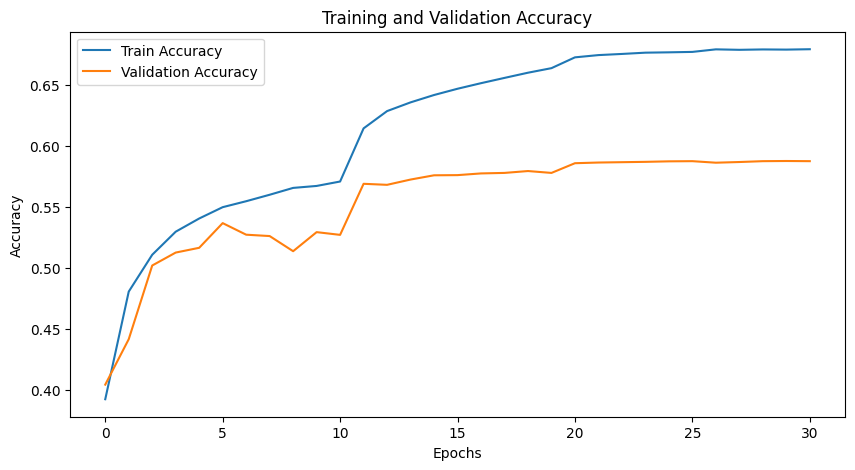

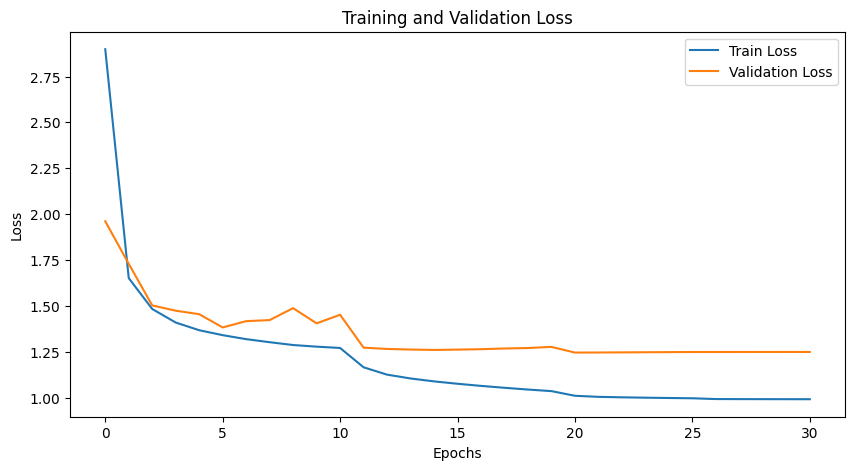

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(face_miniX2_history2.history['accuracy'], label='Train Accuracy')
plt.plot(face_miniX2_history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(face_miniX2_history2.history['loss'], label='Train Loss')
plt.plot(face_miniX2_history2.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()